<a href="https://colab.research.google.com/github/abhayjha800/ML_Projects/blob/main/fruit_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
KAGGLE_KEY = ""

In [3]:
#!/bin/bash
!kaggle datasets download moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
fruits.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile
zip_ref = zipfile.ZipFile('fruits.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn.functional as f
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [7]:
from PIL import Image

In [8]:
BASE_DIR = "/content/fruits-360_100x100/fruits-360"
TRAIN_DIR = os.path.join(BASE_DIR, "Training")
TEST_DIR = os.path.join(BASE_DIR, "Test")

BATCH_SIZE = 64
IMAGE_SIZE = (100, 100)

TARGET_CLASSES = ['Apple Braeburn 1', 'Banana 1', 'Orange 1', 'Lemon 1', 'Kiwi 1', 'Strawberry 1', 'Pomegranate 1']
num_classes = len(TARGET_CLASSES)

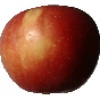

In [9]:
with Image.open(os.path.join(TRAIN_DIR, "Apple Braeburn 1", "0_100.jpg")) as img:
  display(img)

In [10]:
def get_transform():
  """ Returns the training and validation transforms """
  train_transform = transforms.Compose([
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(15),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  val_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  return train_transform, val_transform

In [11]:
class RemappedDataset(torch.utils.data.Dataset):
    """Wraps a subset to remap original class IDs to a clean 0 to N-1 range."""
    def __init__(self, subset, target_indices):
        self.subset = subset
        # Create a dictionary: {original_global_idx: new_local_idx}
        # e.g., {15: 1} if Banana was 15th globally but is 2nd in our target list
        self.mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(target_indices)}

    def __getitem__(self, idx):
        img, old_label = self.subset[idx]
        return img, self.mapping[old_label] # Return the clean, remapped label

    def __len__(self):
        return len(self.subset)

In [12]:
def create_subset_loader(root_dir, transform, target_classes):
  full_dataset = datasets.ImageFolder(root=root_dir, transform=transform)

  target_indices = [
      full_dataset.class_to_idx[class_name]
      for class_name in target_classes
      if class_name in full_dataset.class_to_idx
  ]

  filtered_sample_indices = [
      idx for idx, (_, label) in enumerate(full_dataset.samples)
      if label in target_indices
  ]



  subset_dataset = torch.utils.data.Subset(full_dataset, filtered_sample_indices)
  return RemappedDataset(subset_dataset, target_indices)


In [13]:

train_transform, val_transform = get_transform()

train_dataset = create_subset_loader(TRAIN_DIR, train_transform, TARGET_CLASSES)
test_dataset = create_subset_loader(TEST_DIR, val_transform, TARGET_CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [14]:
class FruitCNN(nn.Module):
  def __init__(self, num_classes):
    super(FruitCNN, self).__init__()

    self.feature_extractor = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.adaptive_poop = nn.AdaptiveAvgPool2d((4, 4))

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.feature_extractor(x)
    x = self.adaptive_poop(x)
    x = self.classifier(x)

    return x

In [15]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [16]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [17]:
model = FruitCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Starting training on: {device}")
print("-" * 40)

# 2. Run the loop
num_epochs = 5
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_model(model, test_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train -> Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
    print(f"  Val   -> Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    print("-" * 40)

print("Training Complete!")

Starting training on: cuda
----------------------------------------
Epoch [1/5]
  Train -> Loss: 0.6158 | Accuracy: 0.7582
  Val   -> Loss: 0.2238 | Accuracy: 0.8743
----------------------------------------
Epoch [2/5]
  Train -> Loss: 0.1435 | Accuracy: 0.9453
  Val   -> Loss: 0.1626 | Accuracy: 0.9367
----------------------------------------
Epoch [3/5]
  Train -> Loss: 0.0993 | Accuracy: 0.9603
  Val   -> Loss: 0.1126 | Accuracy: 0.9473
----------------------------------------
Epoch [4/5]
  Train -> Loss: 0.0544 | Accuracy: 0.9821
  Val   -> Loss: 0.0714 | Accuracy: 0.9754
----------------------------------------
Epoch [5/5]
  Train -> Loss: 0.0538 | Accuracy: 0.9818
  Val   -> Loss: 0.0214 | Accuracy: 0.9938
----------------------------------------
Training Complete!
